# 1. Library Imports

In [2]:
# Numerical and data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and model selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC


**Access Dataset in Colab(Direct Kaggle download)**



In [3]:
!pip install kaggle

# Upload kaggle.json (from your Kaggle account)
from google.colab import files
files.upload()  # select kaggle.json

# Create .kaggle folder & copy token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d ychope/loan-approval-dataset
!unzip loan-approval-dataset.zip


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ychope/loan-approval-dataset
License(s): CC0-1.0
  0% 0.00/5.81M [00:00<?, ?B/s]
100% 5.81M/5.81M [00:00<00:00, 1.21GB/s]
Archive:  loan-approval-dataset.zip
  inflating: Loan.csv                


# 2. Dataset Loading

**Load the dataset**


In [4]:


# Load the dataset
df = pd.read_csv("Loan.csv")
df.head()


,Unnamed: 0,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,high_interest_rate,senior_age
0,126324,151214,2019,ncf,Male,nopre,type1,p3,l1,nopc,...,EXP,35-44,to_inst,70.063920,North,direct,0,42.0,1,0
1,13385,38275,2019,cf,Joint,nopre,type1,p4,l1,nopc,...,EXP,>74,not_inst,40.327381,North,direct,0,40.0,0,1
2,98606,123496,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,...,CIB,55-64,to_inst,49.260355,south,direct,0,29.0,1,1
3,7184,32074,2019,cf,Female,nopre,type1,p3,l1,nopc,...,CIB,35-44,to_inst,74.280576,North,direct,0,44.0,1,0
4,120745,145635,2019,cf,Male,nopre,type1,p1,l1,nopc,...,CIB,35-44,not_inst,99.107143,North,direct,0,42.0,0,0


**2.1 Dataset Overview**

In [5]:
# Display basic information
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (148670, 37)


,Unnamed: 0,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,high_interest_rate,senior_age
0,126324,151214,2019,ncf,Male,nopre,type1,p3,l1,nopc,...,EXP,35-44,to_inst,70.063920,North,direct,0,42.0,1,0
1,13385,38275,2019,cf,Joint,nopre,type1,p4,l1,nopc,...,EXP,>74,not_inst,40.327381,North,direct,0,40.0,0,1
2,98606,123496,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,...,CIB,55-64,to_inst,49.260355,south,direct,0,29.0,1,1
3,7184,32074,2019,cf,Female,nopre,type1,p3,l1,nopc,...,CIB,35-44,to_inst,74.280576,North,direct,0,44.0,1,0
4,120745,145635,2019,cf,Male,nopre,type1,p1,l1,nopc,...,CIB,35-44,not_inst,99.107143,North,direct,0,42.0,0,0


The dataset contains 148,670 rows and 37 columns.

**2.2 Column Names and Data Types**

In [6]:
# Display column names
print("Column Names:\n", df.columns)

# Display data types
print("\nData Types:\n",df.dtypes)


Column Names:
 Index(['Unnamed: 0', 'id', 'year', 'loan_limit', 'gender', 'approv_in_adv',
       'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'income', 'credit_type', 'credit_score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'ltv', 'region', 'security_type',
       'status', 'dtir1', 'high_interest_rate', 'senior_age'],
      dtype='object')

Data Types:
 Unnamed: 0                     int64
id                             int64
year                           int64
loan_limit                    object
gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
credi

This table shows the types of features that will be used after feature selection and encoding. It also highlights the categorical variables that will later be mapped to numerical values using encoding techniques, as described in the Feature Encoding section.

--------------------------------------------------------------------------------




# 3. Initial Data Cleaning

--------------------------------------------------------------------------------

These columns do not carry predictive information and are therefore removed at an early stage of data preprocessing.

 Specifically, the Unnamed: 0, id, and year columns do not contribute to loan approval prediction and are excluded during the data cleaning phase to prevent their use in model training.

In [7]:
# Drop index and identifier columns
df = df.drop(columns=['Unnamed: 0', 'id', 'year'])

print("Remaining columns:", df.shape[1])


Remaining columns: 34


**3.2 Check for Duplicate Rows**

In [8]:
# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicates if any
df = df.drop_duplicates()


Number of duplicate rows: 0


The number of duplicated rows is zero; therefore, no further cleaning is required.

**3.3 Verify Target Variable**

In [9]:
# Check target variable distribution
df['status'].value_counts()


,count
status,
0,112031
1,36639


An analysis of the target variable shows that approved loans are more frequent than rejected loans, with 112,031 approvals and 36,639 rejections.

**3.4 Verify Data Types**




In [10]:
# Inspect data types
df.dtypes


,0
loan_limit,object
gender,object
approv_in_adv,object
loan_type,object
loan_purpose,object
credit_worthiness,object
open_credit,object
business_or_commercial,object
loan_amount,int64
rate_of_interest,float64


**Columns like age, loan_limit, submission_of_application remain as object on purpose — they will be handled after EDA.**

**3.5 Missing Values Overview (Critical for EDA)**

In [11]:
# Missing values count
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display columns with missing values
missing_values[missing_values > 0]


,0
upfront_charges,39642
interest_rate_spread,36639
dtir1,24121
property_value,15098
ltv,15098
income,9150
loan_limit,3344
approv_in_adv,908
submission_of_application,200
age,200


**3.6 Percentage of Missing Values**

In [12]:
# Percentage of missing values
missing_percent = (missing_values / len(df)) * 100

missing_percent[missing_percent > 0].round(2)


,0
upfront_charges,26.66
interest_rate_spread,24.64
dtir1,16.22
property_value,10.16
ltv,10.16
income,6.15
loan_limit,2.25
approv_in_adv,0.61
submission_of_application,0.13
age,0.13


The above output shows the number and percentage of missing (NA) values for each feature. For example, the upfront_charges feature contains approximately 26.66% missing values, while age has only 0.13% missing values.

--------------------------------------------------------------------------------

# 4. Exploratory Data Analysis (EDA)

--------------------------------------------------------------------------------

**4.1 Summary Statistics (Numerical Features)**

In [13]:
# Summary statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,148670.0,2.808830,2.224437,-1.000000,2.75000,3.75000,4.250000,8.000000e+00
interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
credit_score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02
ltv,133572.0,72.746457,39.967603,0.967478,60.47486,75.13587,86.184211,7.831250e+03
status,148670.0,0.246445,0.430942,0.000000,0.00000,0.00000,0.000000,1.000000e+00


**4.2 Target Variable Distribution**

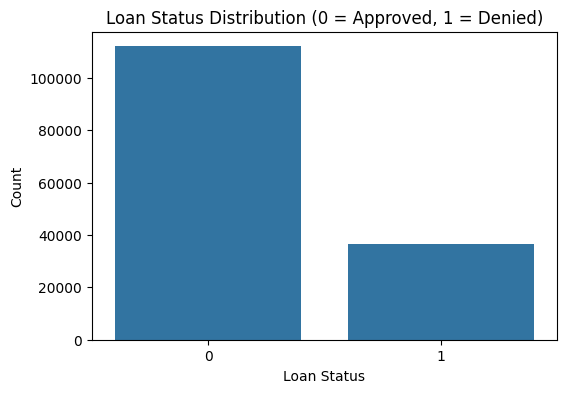

Target Distribution (%):
 status
0    75.355485
1    24.644515
Name: proportion, dtype: float64


In [14]:
# Count plot for target
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title("Loan Status Distribution (0 = Approved, 1 = Denied)")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# Percentage distribution
status_percent = df['status'].value_counts(normalize=True) * 100
print("Target Distribution (%):\n", status_percent)


About 75% of loans are approved, while 25% are disapproved.

**4.3 Numerical Feature Distributions**

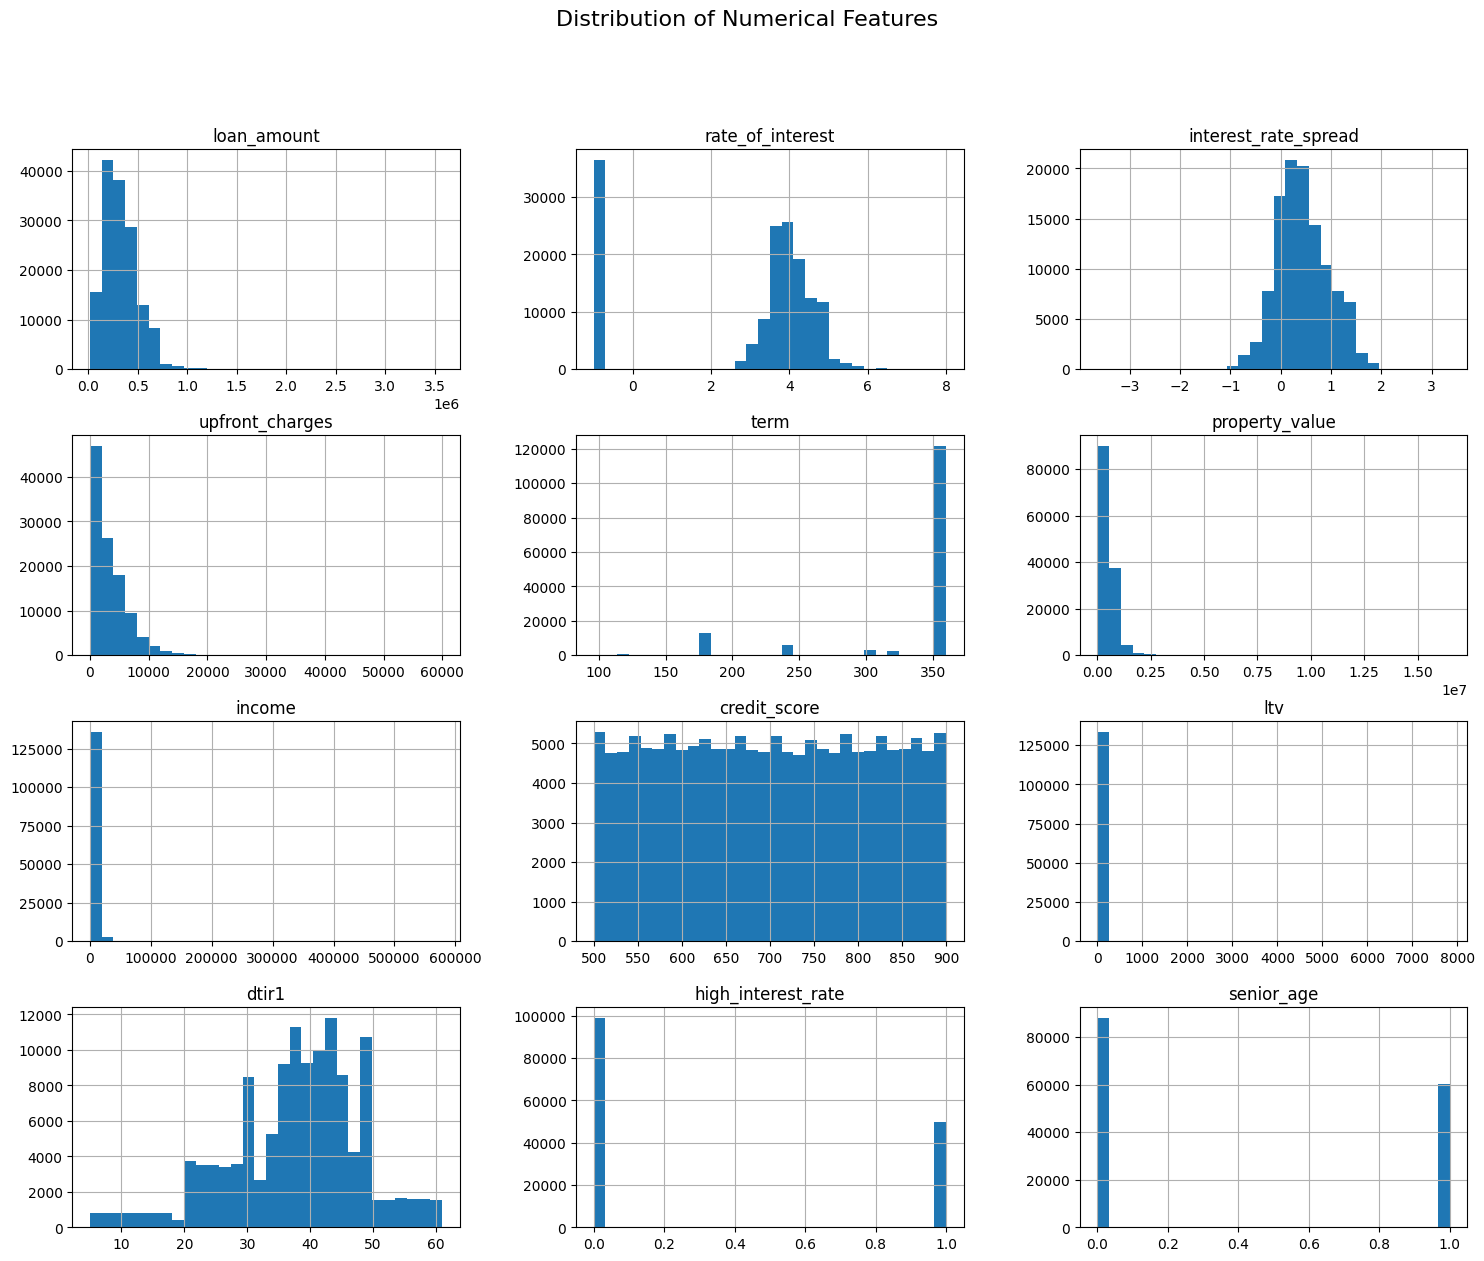

In [15]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.drop('status')

df[numerical_cols].hist(figsize=(18,14), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


The numerical variables show diverse distribution patterns, with financial features such as loan amount, income, property value, and upfront charges being strongly right-skewed, indicating the presence of outliers. Interest-related variables are approximately normally distributed, while ratio-based and binary features show concentrated or discrete distributions, highlighting the importance of feature scaling and preprocessing.

**4.4 Categorical Feature Distributions**

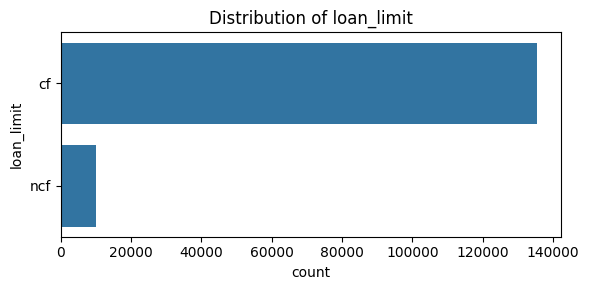

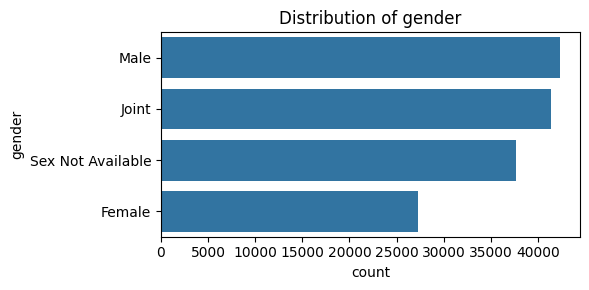

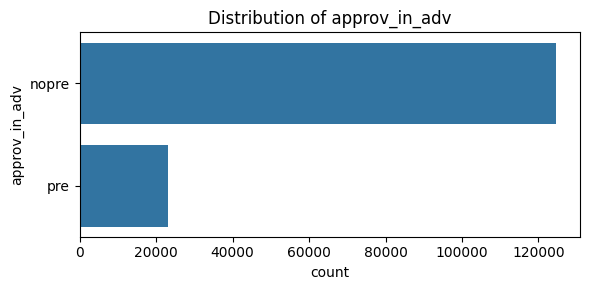

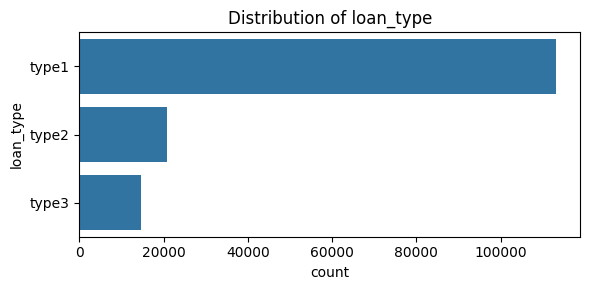

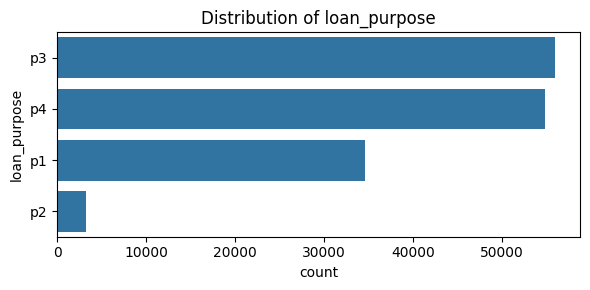

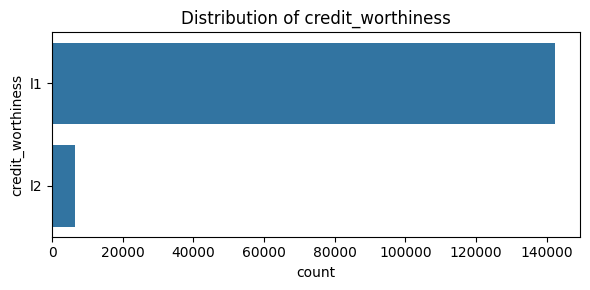

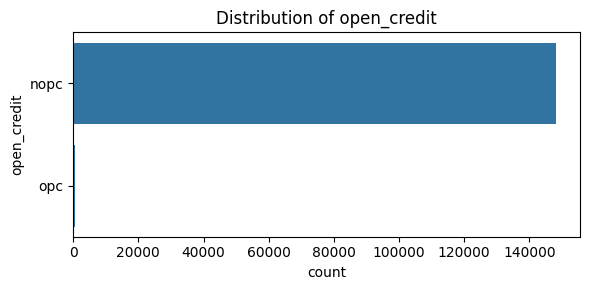

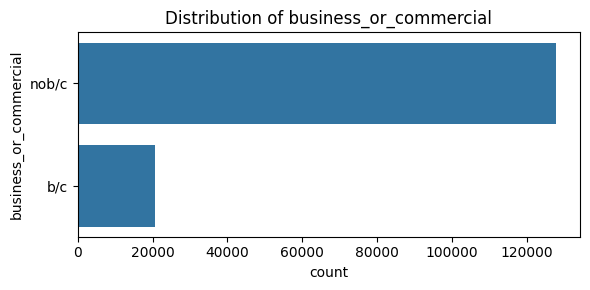

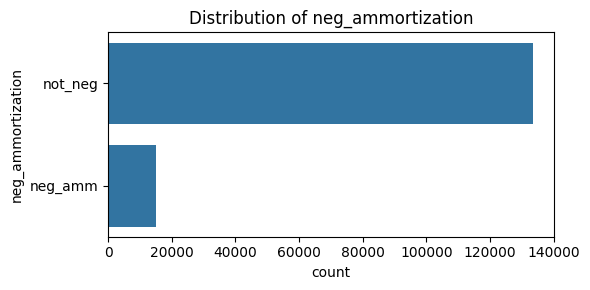

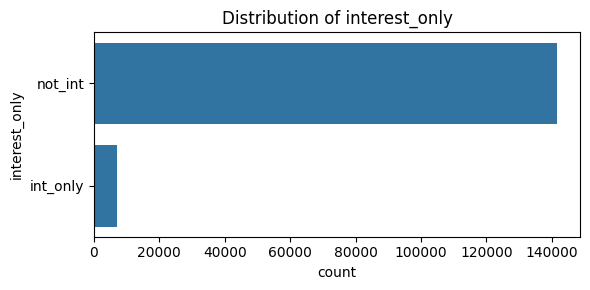

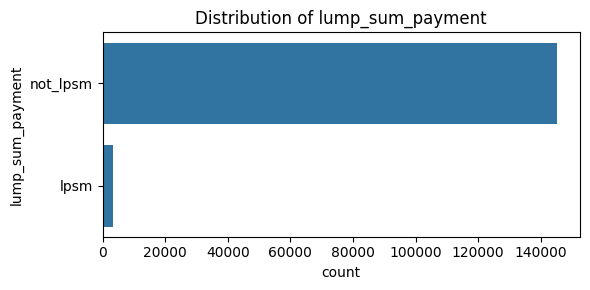

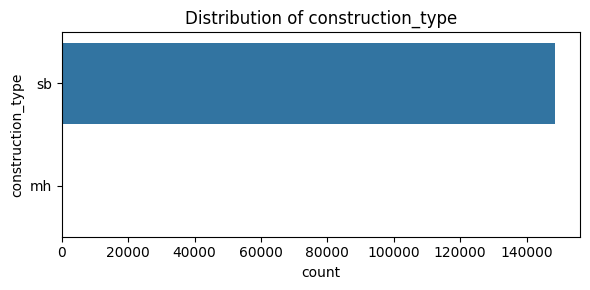

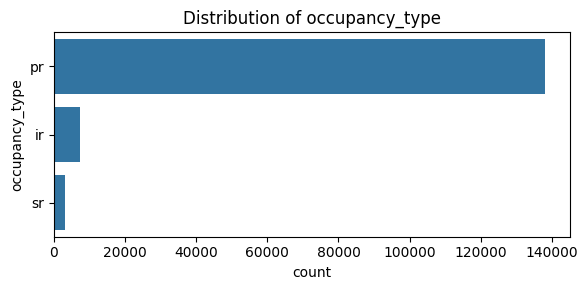

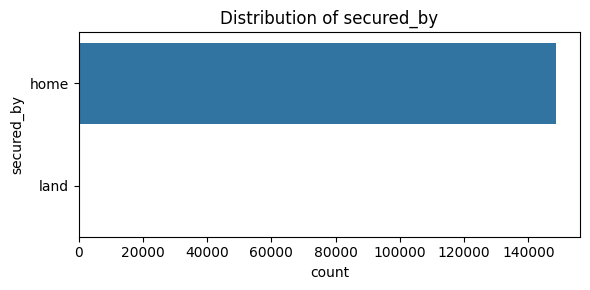

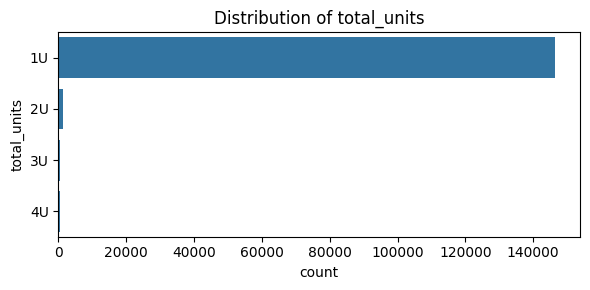

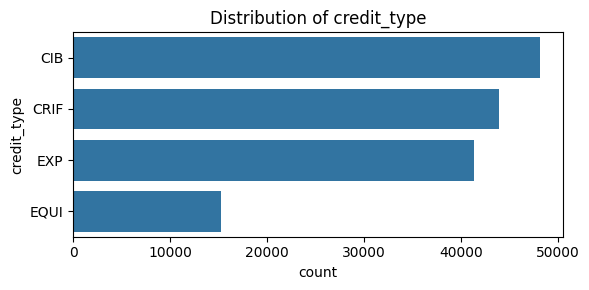

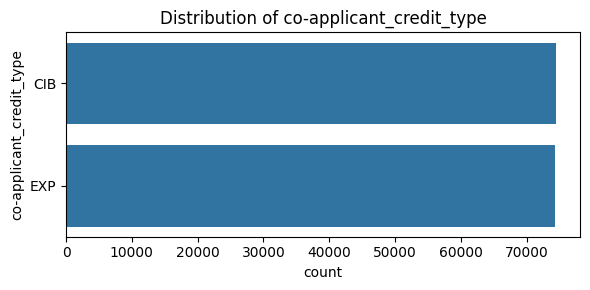

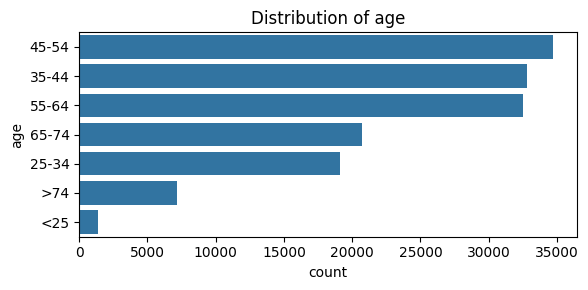

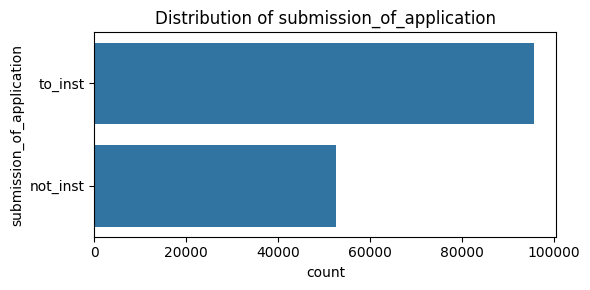

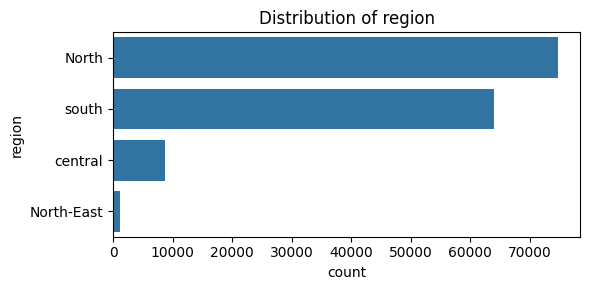

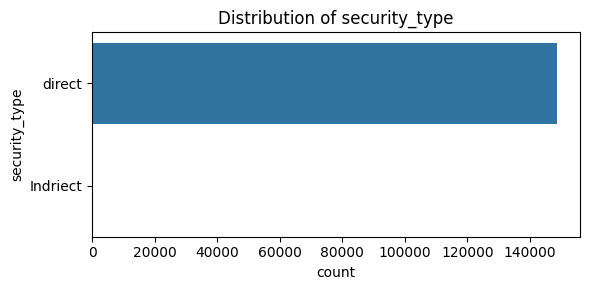

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


**4.5 Relationship Between Key Features and Loan Status**



 ***Credit Score vs Loan Status***

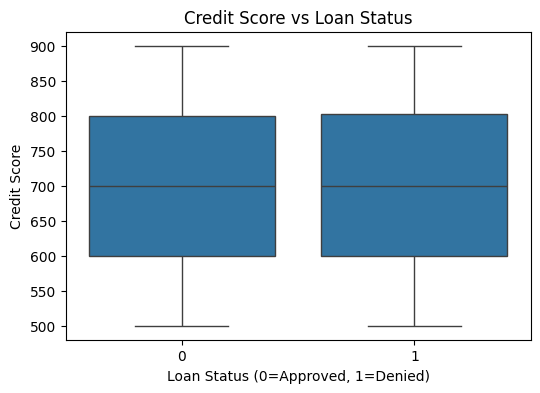

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='credit_score', data=df)
plt.title("Credit Score vs Loan Status")
plt.xlabel("Loan Status (0=Approved, 1=Denied)")
plt.ylabel("Credit Score")
plt.show()


Credit score by itself does not clearly distinguish approved loans from denied loans in this dataset.
Both approved and denied applicants show similar credit score distributions, suggesting that other factors (income, debt ratio, employment, etc.) likely play a significant role in loan decisions.

-  The median credit score for both approved (0) and denied (1) loans is approximately 700.

-  The interquartile range (IQR) is very similar for both groups, roughly spanning 600 to 800.

-  The overall range of credit scores (about 500 to 900) overlaps heavily between approved and denied loans.

***Loan Amount vs Loan Status***

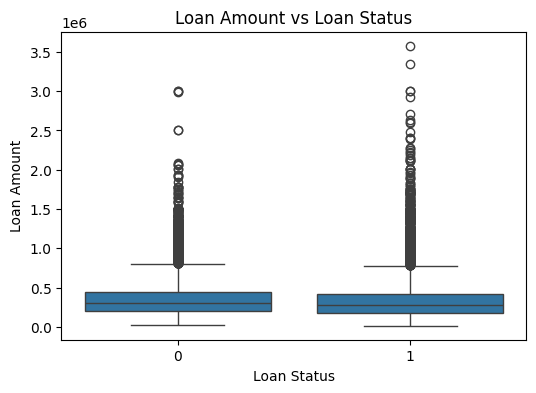

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='loan_amount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()


While there are some differences in extreme values, loan amount by itself does not seem to be a strong predictor of loan status. Additional features would likely be needed to explain differences in loan outcomes.

**4.6 Correlation Analysis**

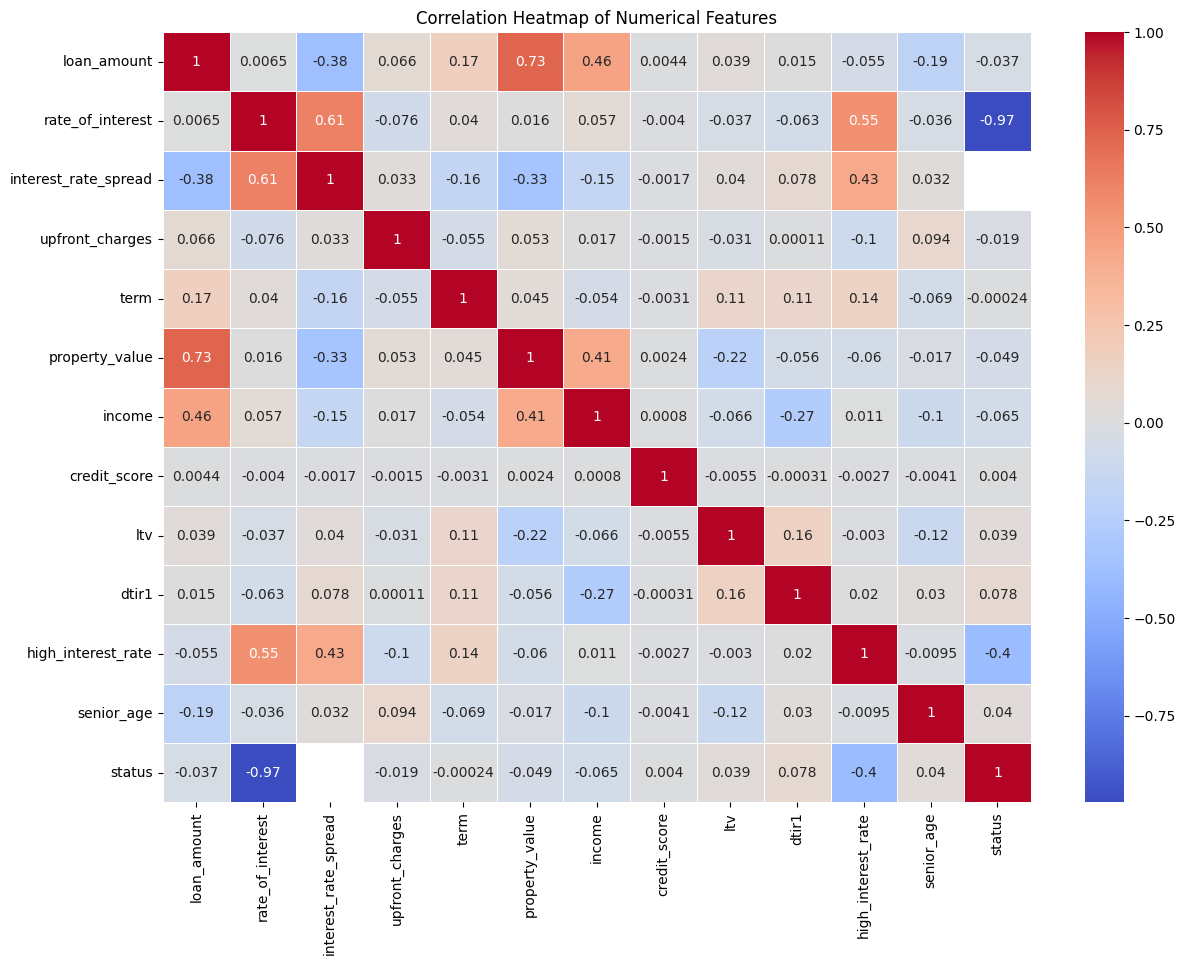

In [19]:
# Correlation matrix
corr_matrix = df[numerical_cols.append(pd.Index(['status']))].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5, annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


This analysis shows the correlation between features and also between features and the target variable. It helps identify features to be removed during feature selection. Specifically, features that exhibit an extremely strong correlation with the target (greater than 90%) may need to be excluded to avoid redundancy or leakage—for example, rate_of_interest shows a strong negative correlation with the target.

# 5. Data Cleaning & Preprocessing

**5.1 Convert numeric columns stored as object to float**


In [20]:
# List of columns that may be numeric but stored as object
numeric_obj_cols = ['loan_limit', 'age', 'total_units', 'submission_of_application']

# Step 1: Inspect unique values / distributions
for col in numeric_obj_cols:
    if col in df.columns:
        print(f"\nColumn: {col}")
        print(df[col].value_counts(dropna=False).head(20))

# Step 2: Convert only the columns that are truly numeric
# From inspection, only 'loan_limit' is numeric-like (replace this with your findings)
numeric_convertible = ['loan_limit']  # Example: if after inspection others are ranges, keep categorical

for col in numeric_convertible:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # invalid parsing becomes NaN

# Step 3: Keep the rest as categorical (do not convert 'age', 'total_units', 'submission_of_application')
categorical_cols_extra = [col for col in numeric_obj_cols if col not in numeric_convertible]
print("\nColumns kept as categorical:", categorical_cols_extra)



Column: loan_limit
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

Column: age
age
45-54    34720
35-44    32818
55-64    32534
65-74    20744
25-34    19142
>74       7175
<25       1337
NaN        200
Name: count, dtype: int64

Column: total_units
total_units
1U    146480
2U      1477
3U       393
4U       320
Name: count, dtype: int64

Column: submission_of_application
submission_of_application
to_inst     95814
not_inst    52656
NaN           200
Name: count, dtype: int64

Columns kept as categorical: ['age', 'total_units', 'submission_of_application']


**5.2 Handling Missing Values**


In [21]:
# Drop columns that are fully empty or useless
df = df.drop(columns=['loan_limit'], errors='ignore')

# Numeric columns (with data)
numeric_cols = ['loan_amount', 'rate_of_interest', 'interest_rate_spread',
                'upfront_charges', 'term', 'property_value', 'income',
                'credit_score', 'ltv', 'status', 'dtir1',
                'high_interest_rate', 'senior_age']

# Fill missing numeric values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_cols = ['gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
                    'credit_worthiness', 'open_credit', 'business_or_commercial',
                    'neg_ammortization', 'interest_only', 'lump_sum_payment',
                    'construction_type', 'occupancy_type', 'secured_by',
                    'total_units', 'credit_type', 'co-applicant_credit_type',
                    'age', 'submission_of_application', 'region', 'security_type']

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify
print("\nMissing values after final cleaning:\n", df.isnull().sum().sort_values(ascending=False))



Missing values after final cleaning:
 gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
credit_worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
interest_rate_spread         0
upfront_charges              0
term                         0
neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
secured_by                   0
total_units                  0
income                       0
credit_type                  0
credit_score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
ltv                          0
region                       0
security_type                0
status                       0
dtir1                        0


Non-informative or empty columns (e.g., loan_limit) were removed. Missing values in numeric features were filled with the median, while missing values in categorical features were replaced with the mode. After this step, the dataset contains no missing values and is ready for modeling.

***Droping the column that shows high correlation with the target(Status)***

In [22]:
#df = df.drop(columns=["dtir1", "upfront_charges","ltv",'rate_of_interest'])
df = df.drop(columns=['rate_of_interest'])
print("Remaining columns:", df.shape[1])


Remaining columns: 32


Here is drobed the column that showed stronng correlation with the target Status.

***Check distributions and value counts for categorical columns***

In [23]:
# Check distributions and value counts for categorical columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    value_counts = df[col].value_counts(dropna=False)  # include NaN if any
    print(value_counts)

# Identify and drop constant columns (only 1 unique value)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
if constant_cols:
    print("\nColumns to drop (constant):", constant_cols)
    df = df.drop(columns=constant_cols)
    print("Shape after dropping constant columns:", df.shape)
else:
    print("\nNo constant columns found")




Column: gender
gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

Column: approv_in_adv
approv_in_adv
nopre    125529
pre       23141
Name: count, dtype: int64

Column: loan_type
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

Column: loan_purpose
loan_purpose
p3    56068
p4    54799
p1    34529
p2     3274
Name: count, dtype: int64

Column: credit_worthiness
credit_worthiness
l1    142344
l2      6326
Name: count, dtype: int64

Column: open_credit
open_credit
nopc    148114
opc        556
Name: count, dtype: int64

Column: business_or_commercial
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64

Column: neg_ammortization
neg_ammortization
not_neg    133541
neg_amm     15129
Name: count, dtype: int64

Column: interest_only
interest_only
not_int     141560
int_only      7110
Name: count, dtype: int64

Column: lump_sum_payment
lum

**Drop highly imbalanced categorical columns**










In [24]:
# Drop highly imbalanced categorical columns
df = df.drop(columns=['construction_type', 'secured_by', 'security_type','interest_rate_spread'])

In [25]:
print("Dataset Shape:", df.shape)


Dataset Shape: (148670, 28)


The number of columns till now are 28.


# Feature Encoding

In [26]:

# Separate target from features first

y = df['status']
X = df.drop(columns=['status'])

#  Ordinal encode age (if present)

if 'age' in X.columns:
    age_map = {
        '<25': 0,
        '25-34': 1,
        '35-44': 2,
        '45-54': 3,
        '55-64': 4,
        '65-74': 5,
        '>74': 6
    }
    X['age_ord'] = X['age'].map(age_map)
    X.drop(columns=['age'], inplace=True)


# Identify categorical columns for One-Hot Encoding (exclude numeric)

cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

#  One-Hot Encode categorical features

if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)



Categorical columns to encode: ['gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit', 'business_or_commercial', 'neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'total_units', 'credit_type', 'co-applicant_credit_type', 'submission_of_application', 'region']


Feature Preparation and Encoding

First, the target variable (status) was separated from the feature set, with y containing the target and X containing all predictors.

The age feature, if present, was ordinally encoded to convert age ranges into numeric values, reflecting their natural order (e.g., <25 → 0, 25-34 → 1, …, >74 → 6). The original age column was then removed.

Next, categorical features were identified for One-Hot Encoding, converting text-based categories into binary indicator variables. This ensures that machine learning models can process these features numerically.

Finally, any boolean columns were converted to integers (0/1), resulting in a fully numeric feature matrix ready for modeling.

In [27]:
X.dtypes


,0
loan_amount,int64
upfront_charges,float64
term,float64
property_value,float64
income,float64
credit_score,int64
ltv,float64
dtir1,float64
high_interest_rate,int64
senior_age,int64


***Split the data into train, validation, test***

In [28]:
#  Split the data into train, validation, test
train_frac = 0.8
val_frac = 0.1
test_frac = 0.1

# Step 1: split out test set (20% of all data)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_frac, random_state=42, stratify=y
)

# Step 2: split remaining into train and validation
val_relative_frac = val_frac / (train_frac + val_frac)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_relative_frac,
    random_state=42, stratify=y_train_val
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (118935, 39)
Validation shape: (14868, 39)
Test shape: (14867, 39)


In [29]:
X_train.head()

,loan_amount,upfront_charges,term,property_value,income,credit_score,ltv,dtir1,high_interest_rate,senior_age,...,total_units_3U,total_units_4U,credit_type_CRIF,credit_type_EQUI,credit_type_EXP,co-applicant_credit_type_EXP,submission_of_application_to_inst,region_North-East,region_central,region_south
143374,446500,0.00,360.0,898000.0,11100.0,681,49.721604,40.0,1,1,...,0,0,1,0,0,0,0,0,0,1
86975,366500,2596.45,360.0,388000.0,4440.0,715,94.458763,52.0,0,0,...,0,0,1,0,0,1,0,0,0,1
100578,436500,4587.92,360.0,628000.0,5700.0,706,69.506369,38.0,1,0,...,0,0,0,0,0,0,1,0,0,1
74947,456500,2596.45,180.0,418000.0,7740.0,767,75.135870,39.0,0,0,...,0,0,0,1,0,1,1,0,0,1
9737,156500,1902.50,360.0,178000.0,2760.0,689,87.921348,38.0,1,0,...,0,0,0,0,1,0,1,0,0,0


# Feature Standardization
Scale numeric features

In [30]:
#  Scale numeric features (fit on TRAIN only!)

# Identify numeric columns (exclude dummy variables)
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()

# Fit on training data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Apply same transformation to validation and test
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Scaling applied to numeric columns:", num_cols)


Scaling applied to numeric columns: ['loan_amount', 'upfront_charges', 'term', 'property_value', 'income', 'credit_score', 'ltv', 'dtir1', 'high_interest_rate', 'senior_age', 'age_ord', 'gender_Joint', 'gender_Male', 'gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2', 'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3', 'loan_purpose_p4', 'credit_worthiness_l2', 'open_credit_opc', 'business_or_commercial_nob/c', 'neg_ammortization_not_neg', 'interest_only_not_int', 'lump_sum_payment_not_lpsm', 'occupancy_type_pr', 'occupancy_type_sr', 'total_units_2U', 'total_units_3U', 'total_units_4U', 'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP', 'co-applicant_credit_type_EXP', 'submission_of_application_to_inst', 'region_North-East', 'region_central', 'region_south']


In this step, all numeric features (excluding dummy variables) were standardized using Z-score normalization. Standardization rescales each numeric feature to have a mean of 0 and a standard deviation of 1, which helps many machine learning models converge faster and perform better.

The formula for Z-score standardization is:

𝑋
scaled=(𝑋−𝜇)/𝜎  

The scaler is fit on the training set (X_train) to compute
μ and σ, and the same transformation is applied to the validation (X_val) and test (X_test) sets. This ensures that no information from the validation or test sets leaks into the training process.
	​


# Modeling

**Neural Network Model (MLP)**

In [31]:
# Neural Network Model (MLP)


mlp_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model with multiple metrics
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='roc_auc')]
)

mlp_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

**MLP Model Overview**

The model is a Multilayer Perceptron (MLP) built for binary classification (predicting loan approval: approved or not). It is a feedforward neural network with the following structure:

-  Input layer: Takes all the features from the training data (X_train.shape[1]).

-  First hidden layer: Dense layer with 64 neurons and ReLU activation, followed by a Dropout layer (0.2) to prevent overfitting.

-  Second hidden layer: Dense layer with 32 neurons and ReLU activation, followed by another Dropout (0.2).

-  Output layer: Dense layer with 1 neuron and sigmoid activation, producing a probability for the target class.

**Summary Table Explained:**

-  *Output Shape:* Shows the size of each layer’s output. For example, (None, 64) means 64 neurons for each input sample (batch size is flexible, hence None).

-  Param #: Number of trainable parameters (weights + biases) in each layer.

-  Total params: 4,673 parameters in the whole network, all trainable.

-  Dropout layers: Have 0 parameters because they only randomly ignore neurons during training.

**Compilation:**

-  Optimizer: Adam with learning rate 0.001.

-  Loss: Binary cross-entropy (suitable for two classes).

-  Metrics: Accuracy, Precision, Recall, ROC-AUC (to evaluate model performance).

In short: This MLP takes numeric features as input, processes them through two hidden layers with dropout for regularization, and outputs a probability for loan approval. The summary shows the network’s size and the number of parameters to learn.

In [32]:
# Train the Model

history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)



Epoch 1/10
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8719 - loss: 0.2894 - precision: 0.8114 - recall: 0.6243 - roc_auc: 0.9056 - val_accuracy: 0.9699 - val_loss: 0.0772 - val_precision: 0.9086 - val_recall: 0.9763 - val_roc_auc: 0.9952
Epoch 2/10
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9643 - loss: 0.0861 - precision: 0.9039 - recall: 0.9571 - roc_auc: 0.9935 - val_accuracy: 0.9779 - val_loss: 0.0620 - val_precision: 0.9210 - val_recall: 0.9959 - val_roc_auc: 0.9965
Epoch 3/10
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9748 - loss: 0.0651 - precision: 0.9211 - recall: 0.9814 - roc_auc: 0.9958 - val_accuracy: 0.9788 - val_loss: 0.0587 - val_precision: 0.9215 - val_recall: 0.9992 - val_roc_auc: 0.9968
Epoch 4/10
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9776 - loss: 0.0576 - precision: 0.9276 - recall: 0.9863 - roc_auc: 0.9965 - val_accuracy: 0.9817 - val_loss: 0.0552 - val_precision: 0.9329 - val_recall: 0.9975 - val_roc_auc

**Evaluate on Test Set**

In [33]:

# Evaluate on Test Set

#  Predict on test set
y_pred_prob = mlp_model.predict(X_test)  # probabilities
y_pred = (y_pred_prob >= 0.5).astype(int)       # binary labels

# 2 Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

#  Create a nice performance table
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'MLP Score': [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4), round(roc, 4)]
})

print("\nMLP Test Set Performance:")
print(performance_df)


465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

MLP Test Set Performance:
      Metric  MLP Score
0   Accuracy     0.9836
1  Precision     0.9421
2     Recall     0.9945
3   F1-Score     0.9676
4    ROC-AUC     0.9977


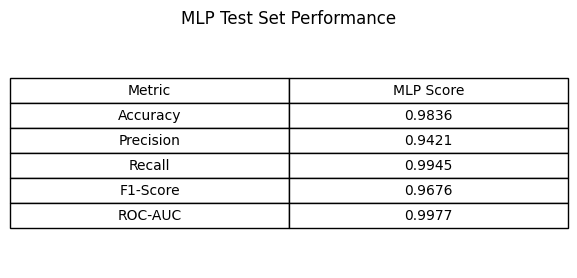

In [34]:

# Create figure
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=performance_df.values,
    colLabels=performance_df.columns,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Title
plt.title("MLP Test Set Performance", fontsize=12, pad=10)

plt.show()


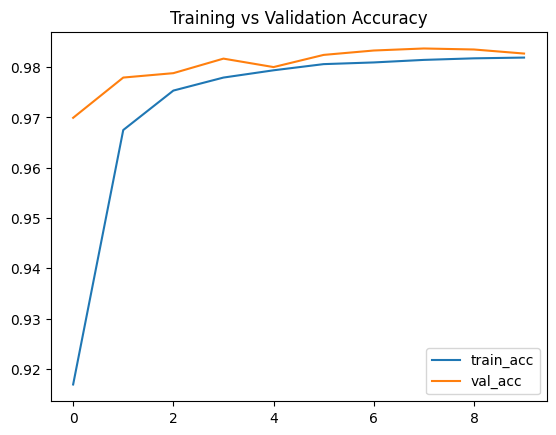

In [35]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


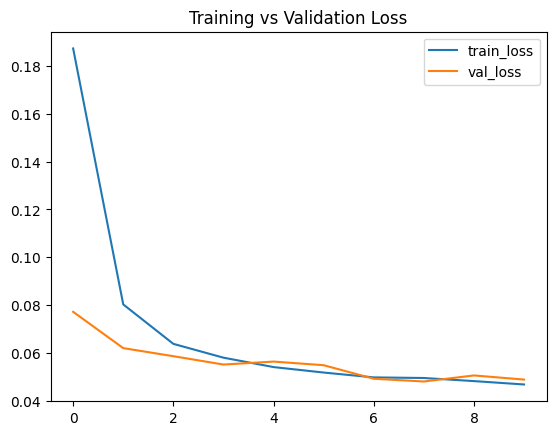

In [36]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

**Confusion Matrix**

465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


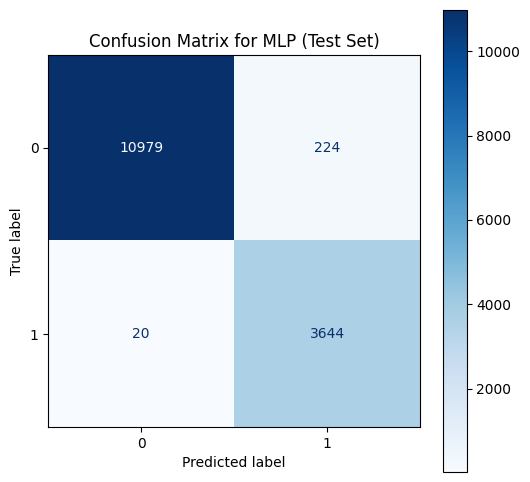

In [37]:

# Confusion Matrix


# Predict test set labels
y_pred_prob = mlp_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp_model.classes_ if hasattr(mlp_model, 'classes_') else [0,1])

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix for MLP (Test Set)")
plt.show()


**ROC Curve**

465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


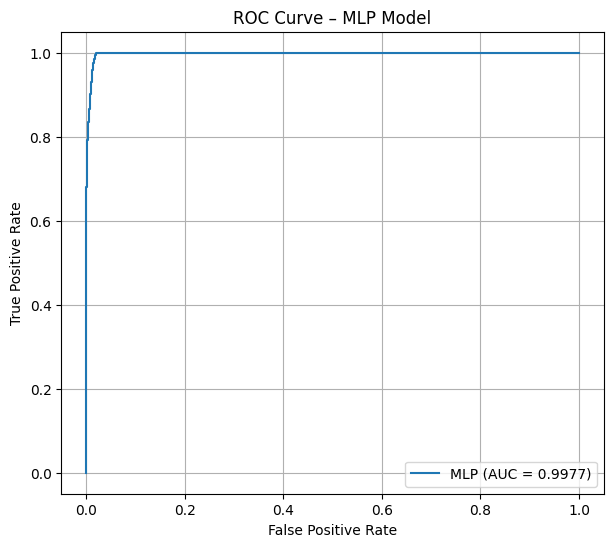

In [38]:
# ROC Curve


# Predict probabilities for the positive class
y_test_prob = mlp_model.predict(X_test).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# Modeling: AdaBoost Classifier

In [39]:

# Import AdaBoost and base estimator
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Base estimator (Decision Tree stump)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize AdaBoost (scikit-learn >=1.2 syntax)
adaboost_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Train AdaBoost on the training set
adaboost_model.fit(X_train, y_train)

# Then, compute validation metrics per iteration
val_acc, val_f1, val_roc = [], [], []

for y_val_pred_iter, y_val_prob_iter in zip(
    adaboost_model.staged_predict(X_val),
    adaboost_model.staged_predict_proba(X_val)
):
    val_acc.append(accuracy_score(y_val, y_val_pred_iter))
    val_f1.append(f1_score(y_val, y_val_pred_iter))
    val_roc.append(roc_auc_score(y_val, y_val_prob_iter[:,1]))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


AdaBoost Model Overview

This section implements an AdaBoost classifier, which is an ensemble method that combines many weak learners (simple models) to make a strong predictor.

Base estimator: A Decision Tree “stump” (a tree with max_depth=1) is used as the weak learner. Each stump can make very simple decisions.

**AdaBoost initialization:**

-  n_estimators=100: 100 weak learners will be combined sequentially.

-  learning_rate=1.0: Controls how much each weak learner contributes to the final model.

-  Training: AdaBoost sequentially trains each decision stump, focusing more on samples that were misclassified by previous stumps.

-  Validation tracking: After each iteration, the code computes accuracy, F1-score, and ROC-AUC on the validation set to monitor performance as more trees are added.
staged_predict and staged_predict_proba allow evaluating the model after each weak learner.

In short: AdaBoost builds a strong model by combining 100 simple decision trees. Each new tree corrects mistakes from the previous ones, and performance metrics are tracked on the validation set to see how the model improves with more trees.

In [40]:
# ----- Predictions -----


# On test set
y_test_pred = adaboost_model.predict(X_test)
y_test_prob = adaboost_model.predict_proba(X_test)[:,1]

# ----- Metrics -----
def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, roc

test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)


In [41]:
# Create a performance DataFrame
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'AdaBoost_Test': [round(m,4) for m in test_metrics]
})

print("\nAdaBoost Performance ( Test):")
print(performance_df)



AdaBoost Performance ( Test):
      Metric  AdaBoost_Test
0   Accuracy         0.9899
1  Precision         0.9621
2     Recall         0.9984
3   F1-Score         0.9799
4    ROC-AUC         0.9985


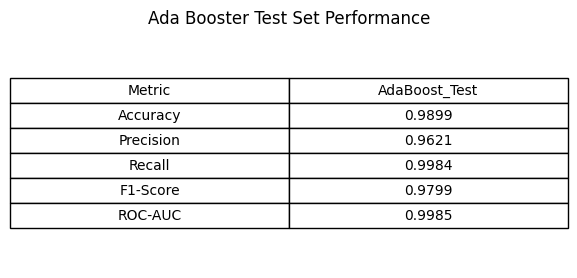

In [42]:

# Create figure
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=performance_df.values,
    colLabels=performance_df.columns,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Title
plt.title("Ada Booster Test Set Performance", fontsize=12, pad=10)

plt.show()

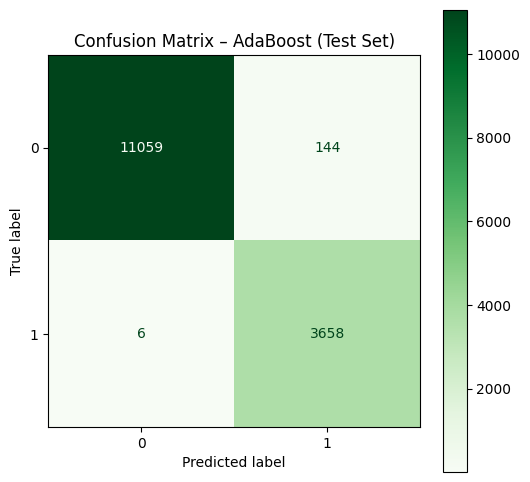

In [43]:
# ----- Confusion Matrix (Test Set) -----
cm_test = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0,1])

plt.figure(figsize=(6,6))
disp.plot(cmap='Greens', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix – AdaBoost (Test Set)")
plt.show()

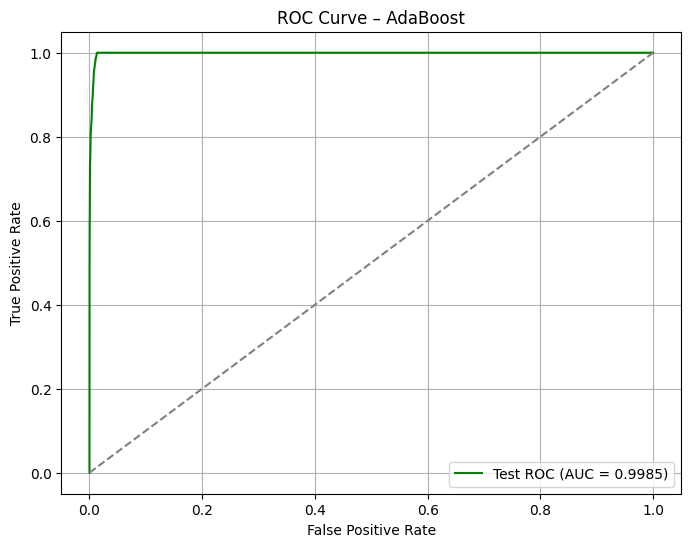

In [44]:
# ----- ROC Curve (Test) -----
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {roc_auc_test:.4f})', color='green')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – AdaBoost")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()